# 10 — Feature selection: all-vehicle baseline (builds on notebook 10)

Same method as the single-vehicle version (notebook 03), applied to the all-vehicle candidate
features from notebook 10: rank by mutual information against a random-noise benchmark, cross-check
with permutation importance from a reference model, and use the corrected **OR** rule (keep if
either signal supports the feature — the stricter AND rule was already shown to wrongly discard
genuinely strong, but redundant, predictors).


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RNG = np.random.default_rng(42)


## 1. Load

In [2]:
df = pd.read_csv("../data/processed/all_vehicles_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

with open("../data/processed/candidate_feature_cols_all_vehicles.json") as f:
    CANDIDATE_FEATURE_COLS = json.load(f)

TARGET = "Fault_Within_6h"
df[TARGET] = df[TARGET].astype(bool)
print(f"{len(df):,} rows, {len(CANDIDATE_FEATURE_COLS)} candidate features.")


175,084 rows, 54 candidate features.


In [3]:
# Same split strategy as notebook 09/10 -- stratified, not chronological, per the coach's spec.
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=42)
print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")


Train: 140,067 rows, Test: 35,017 rows


## 2. Mutual information, with a random-noise benchmark

Run on the complete training set (140,067 rows), not a subsample — an earlier version of this
notebook used a 20,000-row subsample for compute-time reasons; removed per coach feedback that
flagged subsampling as a corner worth closing.

In [4]:
train_df["__random_noise__"] = RNG.normal(size=len(train_df))

mi_input_cols = CANDIDATE_FEATURE_COLS + ["__random_noise__"]
mi_scores = mutual_info_classif(train_df[mi_input_cols], train_df[TARGET], random_state=42)
mi_ranking = pd.Series(mi_scores, index=mi_input_cols).sort_values(ascending=False)

noise_score = mi_ranking["__random_noise__"]
print(f"Random-noise column MI score (the cutoff floor): {noise_score:.6f}")
print(mi_ranking.head(20))

Random-noise column MI score (the cutoff floor): 0.000000
Motor_Torque_roll_mean_24h    0.092643
Motor_RPM_roll_mean_24h       0.092387
Motor_RPM_roll_std_24h        0.089115
Motor_Torque_roll_std_24h     0.088843
Brake_Pad_Wear                0.088410
SOC                           0.081921
hours_since_start             0.080062
SOH                           0.076508
Motor_Torque_roll_std_12h     0.055805
Motor_RPM_roll_std_12h        0.055534
Motor_Torque_roll_mean_12h    0.055512
Motor_RPM_roll_mean_12h       0.055492
Motor_RPM_roll_mean_6h        0.033618
Motor_Torque_roll_mean_6h     0.032975
Motor_Torque_roll_std_6h      0.031578
Motor_RPM_roll_std_6h         0.030729
hour_of_day                   0.026408
Charging_Voltage              0.016537
Tire_Pressure                 0.014186
Motor_RPM_delta_6h            0.010680
dtype: float64


In [5]:
mi_survivors = mi_ranking[(mi_ranking > noise_score) & (mi_ranking.index != "__random_noise__")].index.tolist()
print(f"{len(mi_survivors)} / {len(CANDIDATE_FEATURE_COLS)} candidate features score above the noise floor.")


53 / 54 candidate features score above the noise floor.


### Mutual information ranking, all candidates vs. the random-noise floor


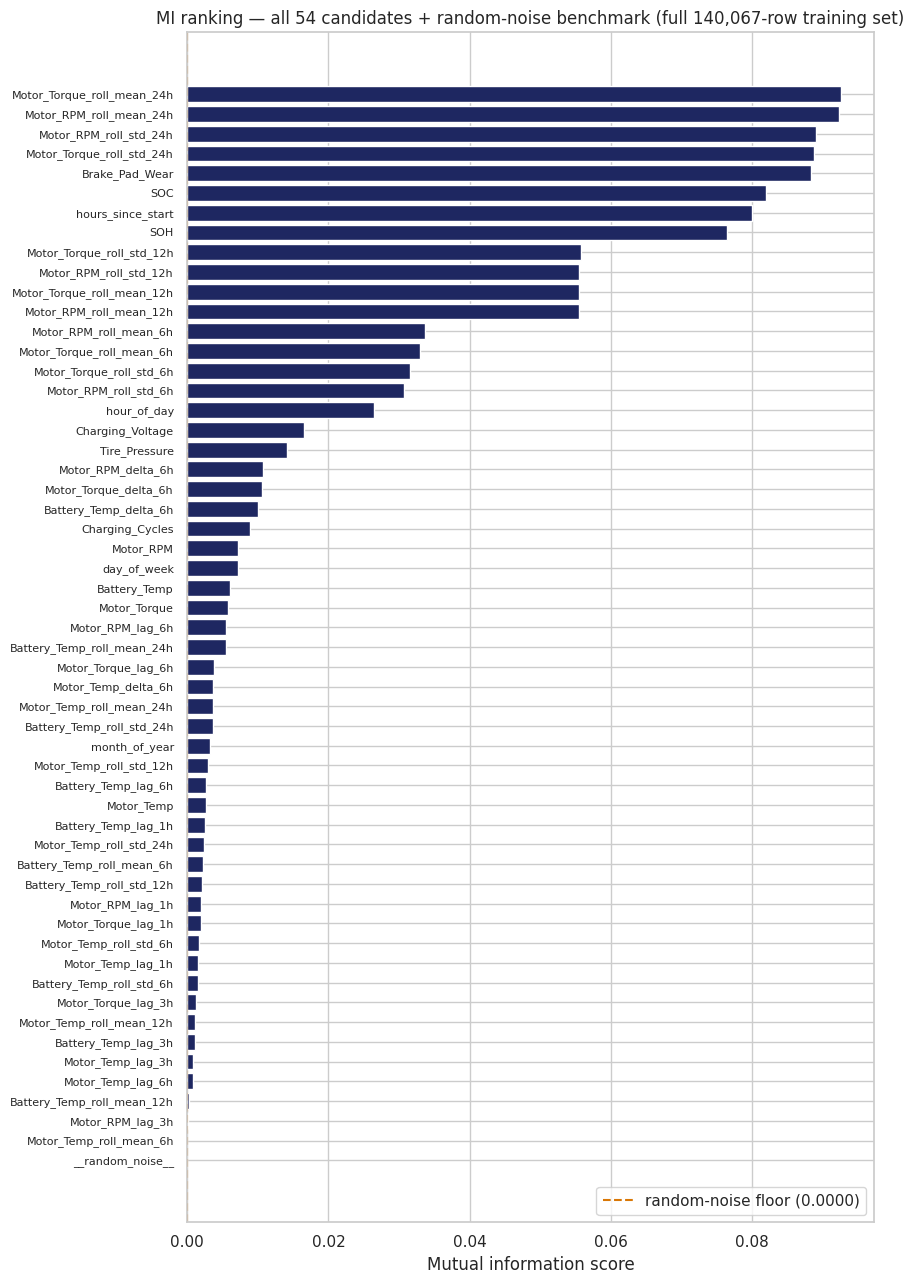

In [6]:
plot_df = mi_ranking.reset_index()
plot_df.columns = ["feature", "mi_score"]
plot_df["is_noise"] = plot_df["feature"] == "__random_noise__"
plot_df = plot_df.sort_values("mi_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 13))
colors = ["#D97706" if is_noise else "#1E2761" for is_noise in plot_df["is_noise"]]
ax.barh(plot_df["feature"], plot_df["mi_score"], color=colors)
ax.axvline(noise_score, color="#D97706", linestyle="--", linewidth=1.5,
           label=f"random-noise floor ({noise_score:.4f})")
ax.set_xlabel("Mutual information score")
ax.set_title("MI ranking — all 54 candidates + random-noise benchmark (full 140,067-row training set)")
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 3. Permutation importance — reference Random Forest, MI survivors only

Fit and evaluated on the full train (140,067 rows) / test (35,017 rows) split, not a subsample —
same fix as the MI step above.

In [7]:
rf_check = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=80, max_depth=8, class_weight="balanced",
                                    random_state=42, n_jobs=-1)),
])
rf_check.fit(train_df[mi_survivors], train_df[TARGET])

perm = permutation_importance(rf_check, test_df[mi_survivors], test_df[TARGET],
                               scoring="f1", n_repeats=5, random_state=42, n_jobs=-1)
perm_ranking = pd.Series(perm.importances_mean, index=mi_survivors).sort_values(ascending=False)
print(perm_ranking.head(20))

hour_of_day                   0.024503
day_of_week                   0.014701
Tire_Pressure                 0.012511
Charging_Voltage              0.007884
Motor_Torque_roll_mean_24h    0.006965
Motor_RPM_roll_mean_24h       0.006935
Battery_Temp_roll_mean_24h    0.003756
SOH                           0.001530
Charging_Cycles               0.001425
Battery_Temp_roll_mean_6h     0.001300
Brake_Pad_Wear                0.001014
hours_since_start             0.000886
Motor_Temp_roll_mean_24h      0.000797
Motor_RPM_roll_std_24h        0.000750
Battery_Temp_roll_std_24h     0.000747
Battery_Temp_lag_1h           0.000606
Motor_RPM_lag_1h              0.000571
Motor_Torque_roll_std_24h     0.000470
Motor_RPM_lag_3h              0.000437
Motor_Torque_lag_1h           0.000436
dtype: float64


### Permutation importance, MI survivors only


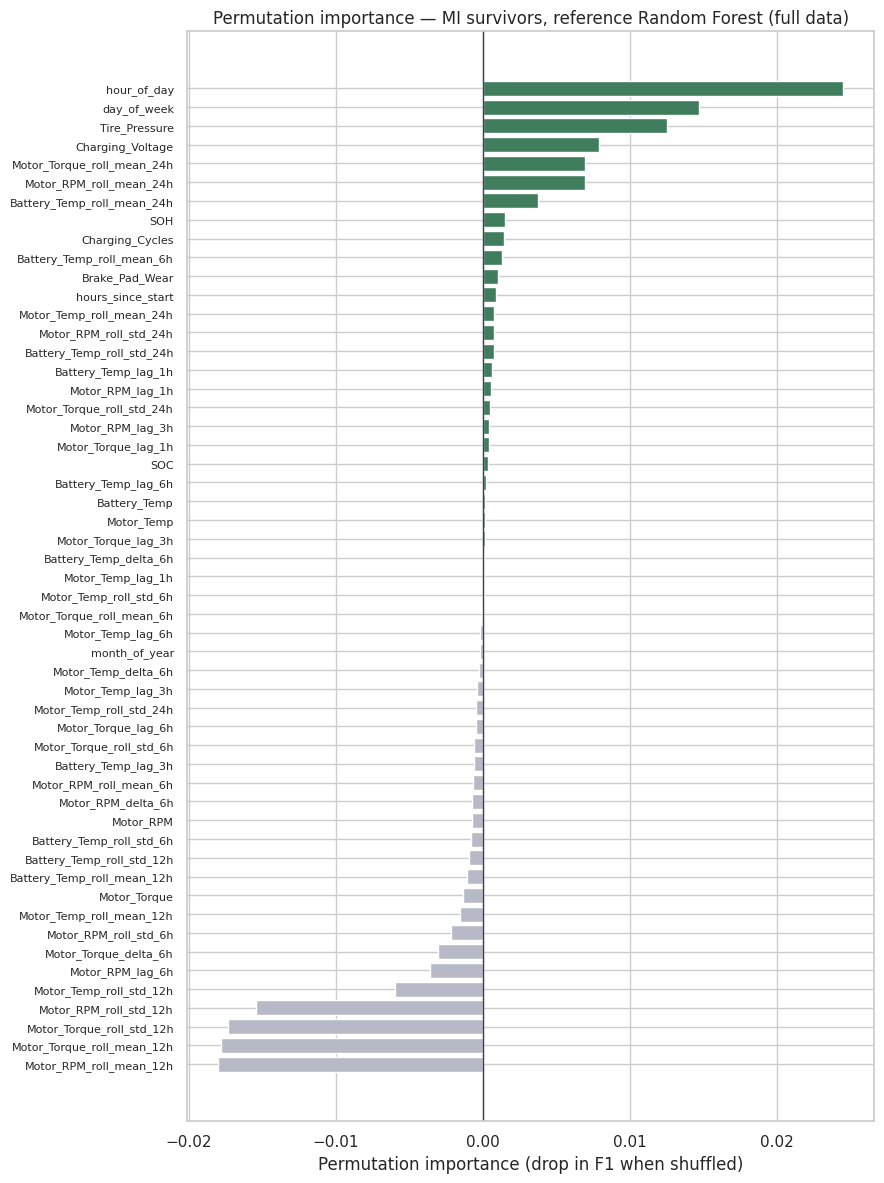

In [8]:
plot_df2 = perm_ranking.reset_index()
plot_df2.columns = ["feature", "perm_importance"]
plot_df2 = plot_df2.sort_values("perm_importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 12))
colors2 = ["#3F7D5C" if v > 0 else "#B7BAC6" for v in plot_df2["perm_importance"]]
ax.barh(plot_df2["feature"], plot_df2["perm_importance"], color=colors2)
ax.axvline(0, color="#3A3F52", linewidth=1)
ax.set_xlabel("Permutation importance (drop in F1 when shuffled)")
ax.set_title("Permutation importance — MI survivors, reference Random Forest (full data)")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 4. Corrected decision rule — keep if MI-vs-noise **OR** permutation importance positive

Same fix applied here as in the single-vehicle version: requiring both checks to pass wrongly
discards features that are genuinely predictive but redundant with another feature already in the
reference model (e.g. two rolling features on correlated sensors). Dropping only when a feature
fails *both* checks avoids that mistake.


In [9]:
perm_positive_set = set(perm_ranking[perm_ranking > 0].index)
mi_survivor_set = set(mi_survivors)

SELECTED_FEATURE_COLS = [f for f in CANDIDATE_FEATURE_COLS
                          if f in mi_survivor_set or f in perm_positive_set]

print(f"Candidate features: {len(CANDIDATE_FEATURE_COLS)}")
print(f"Survived MI-vs-noise: {len(mi_survivors)}")
print(f"Survived MI OR permutation importance: {len(SELECTED_FEATURE_COLS)}")
print()
print("Dropped:")
print(sorted(set(CANDIDATE_FEATURE_COLS) - set(SELECTED_FEATURE_COLS)))


Candidate features: 54
Survived MI-vs-noise: 53
Survived MI OR permutation importance: 53

Dropped:
['Motor_Temp_roll_mean_6h']


In [10]:
with open("../data/processed/selected_feature_cols_all_vehicles.json", "w") as f:
    json.dump(SELECTED_FEATURE_COLS, f, indent=2)

print(f"Saved {len(SELECTED_FEATURE_COLS)} selected features to "
      f"../data/processed/selected_feature_cols_all_vehicles.json")


Saved 53 selected features to ../data/processed/selected_feature_cols_all_vehicles.json


## 5. What this notebook establishes, going into notebook 12

A real, checked feature selection step exists for the all-vehicle track too, using the same
noise-floor + permutation-importance method (with the corrected OR rule) as the single-vehicle
version. Notebook 11's tree models train only on `SELECTED_FEATURE_COLS`, not the full candidate
list.
